Exploratory data analysis (EDA) is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [45]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns

import plotly.express as px
from pathlib import Path

from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [46]:
# Load the movies dataset

file_path = Path("automobile.txt")
df = pd.read_csv(file_path, sep=",", na_values=["?", "NA", "N/A", ""])
print("Shape:", df.shape)
df.head()

Shape: (205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### Data Cleansing
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [47]:
#  Remove redundant columns
columns_to_remove = ['normalized-losses', 'symboling']
df = df.drop(columns=columns_to_remove, errors='ignore')
print(f"Removed columns: {columns_to_remove}")


Removed columns: ['normalized-losses', 'symboling']


#### Remove any duplicate rows

In [48]:
duplicates = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {duplicates} duplicate rows.")
print("New shape:", df.shape)

Removed 0 duplicate rows.
New shape: (205, 24)


#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [49]:
missing_before = df.isnull().sum().sum()
df = df.dropna(axis=0).reset_index(drop=True)
missing_after = df.isnull().sum().sum()
print(f"Removed {missing_before - missing_after} rows containing missing data.")
print("Remaining rows:", df.shape[0])

Removed 18 rows containing missing data.
Remaining rows: 193


Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [50]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    df[col] = df[col].astype(np.int64)
print("Converted numeric columns to int64.")
df.dtypes.head()

Converted numeric columns to int64.


make            object
fuel-type       object
aspiration      object
num-of-doors    object
body-style      object
dtype: object

### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [51]:
# Create a dataframe with all the cars in the "hatchback' category
# hatchback_cars =

hatchback_cars = df[df['body-style'].str.lower() == 'hatchback']
print(f"Number of hatchback cars: {len(hatchback_cars)}")
hatchback_cars.head()


Number of hatchback cars: 63


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
2,alfa-romero,gas,std,two,hatchback,rwd,front,94,171,65,...,152,mpfi,2,3,9,154,5000,19,26,16500
17,chevrolet,gas,std,two,hatchback,fwd,front,88,141,60,...,61,2bbl,2,3,9,48,5100,47,53,5151
18,chevrolet,gas,std,two,hatchback,fwd,front,94,155,63,...,90,2bbl,3,3,9,70,5400,38,43,6295
20,dodge,gas,std,two,hatchback,fwd,front,93,157,63,...,90,2bbl,2,3,9,68,5500,37,41,5572
21,dodge,gas,std,two,hatchback,fwd,front,93,157,63,...,90,2bbl,2,3,9,68,5500,31,38,6377


### Now onto the exploration

#### Identify relationships between variables (features)

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

Top 5 Most Expensive Cars:


,make,body-style,price,city-mpg,highway-mpg
65,mercedes-benz,hardtop,45400,14,16
15,bmw,sedan,41315,16,22
64,mercedes-benz,sedan,40960,14,16
119,porsche,convertible,37028,17,25
16,bmw,sedan,36880,15,20


5 Cheapest Cars:


,make,body-style,price,city-mpg,highway-mpg
126,subaru,hatchback,5118,31,36
17,chevrolet,hatchback,5151,47,53
46,mazda,hatchback,5195,30,31
138,toyota,hatchback,5348,35,39
67,mitsubishi,hatchback,5389,37,41


C:\Users\matho\AppData\Local\Temp\ipykernel_21804\4293415533.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\matho\AppData\Local\Temp\ipykernel_21804\4293415533.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




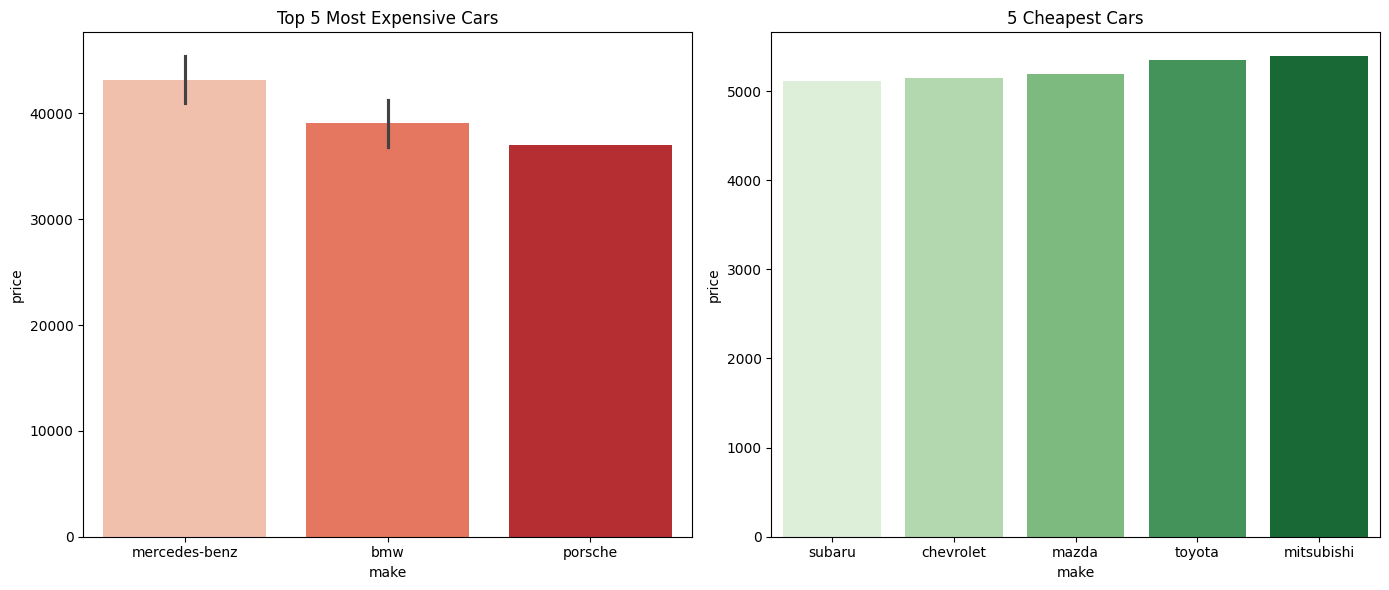

In [52]:
# --- Step: Data Exploration ---
# Question : Which are the 5 most expensive cars?

top_5_expensive = df.sort_values(by='price', ascending=False).head(5)
bottom_5_cheap = df.sort_values(by='price', ascending=True).head(5)

print("Top 5 Most Expensive Cars:")
display(top_5_expensive[['make', 'body-style', 'price', 'city-mpg', 'highway-mpg']])

print("5 Cheapest Cars:")
display(bottom_5_cheap[['make', 'body-style', 'price', 'city-mpg', 'highway-mpg']])

# Plot comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x='make', y='price', data=top_5_expensive, ax=ax[0], palette='Reds')
ax[0].set_title('Top 5 Most Expensive Cars')
sns.barplot(x='make', y='price', data=bottom_5_cheap, ax=ax[1], palette='Greens')
ax[1].set_title('5 Cheapest Cars')
plt.tight_layout()
plt.show()




#### Which manufacturer builds the most fuel efficient vehicles?

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

In [53]:
# --- Which manufacturer builds the most fuel-efficient vehicles? ---

avg_mpg = (
    df.groupby('make', as_index=False)[['city-mpg', 'highway-mpg']]
    .mean()
    .sort_values(by='city-mpg', ascending=False)
)

fig = px.bar(
    avg_mpg,
    x='make', y='city-mpg',
    color='city-mpg',
    title='Average City MPG per Manufacturer',
)
fig.update_layout(xaxis_title='Manufacturer', yaxis_title='Average City MPG')
fig.show()

best_mpg = avg_mpg.head(5)
print("Top 5 Fuel Efficient Manufacturers:")
display(best_mpg)





Top 5 Fuel Efficient Manufacturers:


,make,city-mpg,highway-mpg
3,chevrolet,41.000000,46.333333
5,honda,30.384615,35.461538
19,volkswagen,28.583333,34.916667
4,dodge,28.500000,34.625000
14,plymouth,28.142857,34.142857


#### Which vehicles have the largest engine capacity.
Sort the dataframe based on the engine-size column.

Top 10 Vehicles with the Largest Engine Capacity:


,make,body-style,engine-size,horsepower,price
45,jaguar,sedan,326,262,36000
64,mercedes-benz,sedan,308,184,40960
65,mercedes-benz,hardtop,304,184,45400
44,jaguar,sedan,258,176,35550
43,jaguar,sedan,258,176,32250
62,mercedes-benz,sedan,234,155,34184
63,mercedes-benz,convertible,234,155,35056
16,bmw,sedan,209,182,36880
14,bmw,sedan,209,182,30760
15,bmw,sedan,209,182,41315


C:\Users\matho\AppData\Local\Temp\ipykernel_21804\1419122589.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




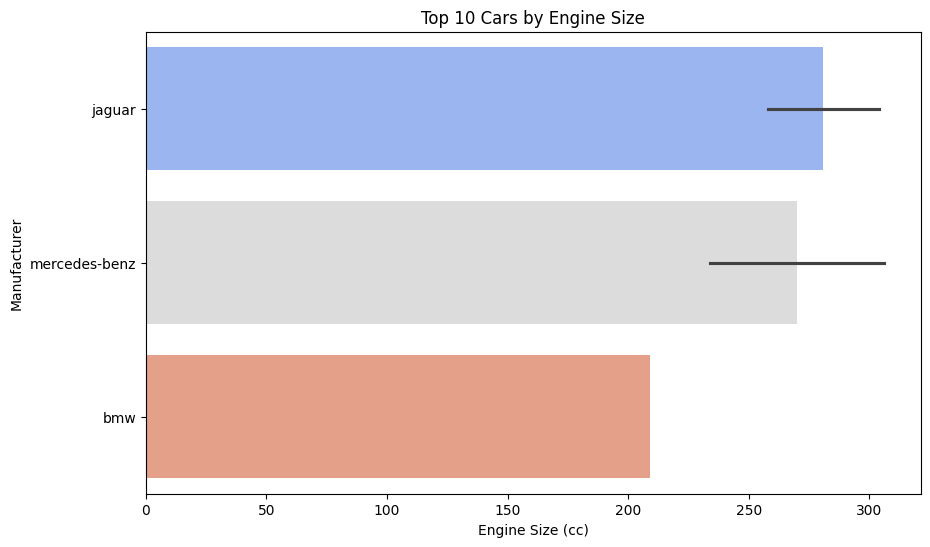

In [54]:
# --- Vehicles with the largest engine capacity ---

df_sorted_engine = df.sort_values(by='engine-size', ascending=False)
top_engine = df_sorted_engine[['make', 'body-style', 'engine-size', 'horsepower', 'price']].head(10)

print("Top 10 Vehicles with the Largest Engine Capacity:")
display(top_engine)

plt.figure(figsize=(10, 6))
sns.barplot(x='engine-size', y='make', data=top_engine, palette='coolwarm')
plt.title('Top 10 Cars by Engine Size')
plt.xlabel('Engine Size (cc)')
plt.ylabel('Manufacturer')
plt.show()



#### Which vehicle manufacturer has the most car models in the dataset

In [55]:
#  --- Which manufacturer has the most car models? ---

model_count = df['make'].value_counts().head(10)

fig = px.bar(
    x=model_count.index,
    y=model_count.values,
    title='Top 10 Manufacturers by Number of Models',
    color=model_count.values,
    color_continuous_scale='viridis'
)
fig.update_layout(xaxis_title='Manufacturer', yaxis_title='Number of Models')
fig.show()

print("Top manufacturers by number of models:")
print(model_count)



Top manufacturers by number of models:
make
toyota        32
nissan        18
honda         13
mitsubishi    13
volkswagen    12
subaru        12
mazda         12
volvo         11
peugot        11
bmw            8
Name: count, dtype: int64


#### EDA REPORT

In [56]:
# EDA Report Generation
# Generates a PDF including major charts and findings.

import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plots_dir = Path("automobile_plots")
plots_dir.mkdir(exist_ok=True)

try:
    # Price Distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(df["price"], bins=30, kde=True, color="teal")
    plt.title("Distribution of Car Prices")
    plt.xlabel("Price (USD)")
    plt.ylabel("Count")
    price_plot = plots_dir / "price_distribution.png"
    plt.savefig(price_plot, dpi=150, bbox_inches="tight")
    plt.close()

    # Top Manufacturers by Number of Models
    model_count = df["make"].value_counts().head(5)
    fig = px.bar(
        x=model_count.index,
        y=model_count.values,
        title="Top 5 Manufacturers by Number of Models",
        color=model_count.values,
        color_continuous_scale="viridis"
    )
    top_makes_plot = plots_dir / "top_makes.png"
    fig.write_image(str(top_makes_plot))

    # Correlation Heatmap
    num_df = df.select_dtypes(include=[np.number])
    plt.figure(figsize=(10, 8))
    sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
    plt.title("Correlation Heatmap (Numerical Features)")
    heatmap_plot = plots_dir / "correlation_heatmap.png"
    plt.savefig(heatmap_plot, dpi=150, bbox_inches="tight")
    plt.close()

    # Most Expensive Cars
    top_expensive = df.sort_values(by="price", ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(x="price", y="make", data=top_expensive, palette="Reds_r")
    plt.title("Top 10 Most Expensive Cars")
    plt.xlabel("Price (USD)")
    plt.ylabel("Manufacturer")
    expensive_plot = plots_dir / "top_expensive_cars.png"
    plt.savefig(expensive_plot, dpi=150, bbox_inches="tight")
    plt.close()

    # Most Fuel-Efficient Manufacturers
    avg_mpg = (
        df.groupby("make", as_index=False)[["city-mpg", "highway-mpg"]]
        .mean()
        .sort_values(by="city-mpg", ascending=False)
        .head(10)
    )
    plt.figure(figsize=(10, 6))
    sns.barplot(x="city-mpg", y="make", data=avg_mpg, palette="Greens_r")
    plt.title("Top 10 Most Fuel-Efficient Manufacturers (City MPG)")
    plt.xlabel("Average City MPG")
    plt.ylabel("Manufacturer")
    mpg_plot = plots_dir / "fuel_efficient_makes.png"
    plt.savefig(mpg_plot, dpi=150, bbox_inches="tight")
    plt.close()

    # Largest Engine Capacity
    top_engine = df.sort_values(by="engine-size", ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(x="engine-size", y="make", data=top_engine, palette="Blues_r")
    plt.title("Top 10 Cars with the Largest Engine Capacity")
    plt.xlabel("Engine Size")
    plt.ylabel("Manufacturer")
    engine_plot = plots_dir / "largest_engine_capacity.png"
    plt.savefig(engine_plot, dpi=150, bbox_inches="tight")
    plt.close()

    print(" Saved all visualisation images successfully!")

except Exception as e:
    print(" Error saving plots:", e)


# --- Create PDF Report ---
try:
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
    from reportlab.lib.styles import getSampleStyleSheet
    from reportlab.lib.pagesizes import A4
    from reportlab.lib.units import inch


    pdf_path = Path("EDA Report - Automobile Dataset.pdf")
    doc = SimpleDocTemplate(str(pdf_path), pagesize=A4)
    styles = getSampleStyleSheet()
    elems = []

    # Title and Introduction
    elems.append(Paragraph("EDA Report – Automobile Dataset", styles["Title"]))
    elems.append(Spacer(1, 12))
    elems.append(Paragraph(
        "This Exploratory Data Analysis (EDA) report presents an overview of the Automobile dataset. "
        "The report details the cleaning steps, treatment of missing data, and visual analysis of "
        "vehicle prices, fuel efficiency, engine capacity, and manufacturer trends.",
        styles["Normal"]
    ))

    # Data cleaning
    elems.append(Spacer(1, 24))
    elems.append(Paragraph("Data cleaning", styles["Title"]))
    elems.append(Spacer(1, 12))
    steps = [
        "The raw Automobile dataset contained redundant and inconsistent data.",
        "Key cleaning steps included:",
        "Removed columns: Dropped `normalized-losses` and `symboling` as they were not needed."
        "Removed duplicate rows using `drop_duplicates()`.",
        "Missing values: Replaced with `NaN` and removed incomplete rows with `dropna()`.",
        "Data types: Converted numeric columns to `int64` using `pd.to_numeric()`.",
        "Column names: Standardised names to lowercase for consistency.",
        "The cleaned dataset was then used for analysis and visualisations."
    ]

    for step in steps:
        elems.append(Paragraph(step, styles["Normal"]))

    # Missing Data
    elems.append(Spacer(1, 24))
    elems.append(Paragraph("Missing Data", styles["Title"]))
    elems.append(Spacer(1, 12))
    elems.append(Paragraph(
        "Some rows had missing entries for price, horsepower, and other numeric fields."  
        "To maintain data accuracy, all rows with missing values were removed."  
        "After cleaning, the dataset contained no missing values, ensuring reliable analysis.",
        styles["Normal"]
    ))
    elems.append(Spacer(1, 24))

    # Add images to the PDF
    for img_file, caption in [
        ("price_distribution.png", "Distribution of Car Prices"),
        ("top_expensive_cars.png", "Top 5 Most Expensive Cars"),
        ("fuel_efficient_makes.png", "Top 10 Most Fuel-Efficient Manufacturers"),
        ("largest_engine_capacity.png", "Top 10 Cars with Largest Engine Capacity"),
        ("top_makes.png", "Top 10 Manufacturers by Number of Models"),
        ("correlation_heatmap.png", "Correlation Heatmap of Numerical Features")
    ]:
        img_path = plots_dir / img_file
        if img_path.exists():
            elems.append(Image(str(img_path), width=6*inch, height=4*inch))
            elems.append(Spacer(1, 8))
            elems.append(Paragraph(caption, styles["Italic"]))
            elems.append(Spacer(1, 16))

    # Conclusion paragraph
    elems.append(Paragraph(
        "In summary, this analysis indicates that engine size, horsepower, and curb weight "
        "are strong predictors of price. Manufacturers producing high-performance vehicles "
        "also dominate the upper end of the price spectrum. Meanwhile, smaller engines "
        "and lighter cars tend to be more fuel-efficient, as shown in the city MPG comparisons.",
        styles["Normal"]
    ))

    # Author
    elems.append(Spacer(1, 24))
    elems.append(Paragraph(
        "This report was written by: Nyandano Mathoma.",
        styles["Italic"]
    ))
    # Build the PDF
    doc.build(elems)
    print(f" PDF successfully created at: {pdf_path.resolve()}")

except Exception as e:
    print(" PDF creation failed. Ensure 'reportlab' and 'kaleido' are installed. Error:", e)



C:\Users\matho\AppData\Local\Temp\ipykernel_21804\3686560085.py:48: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\matho\AppData\Local\Temp\ipykernel_21804\3686560085.py:64: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\matho\AppData\Local\Temp\ipykernel_21804\3686560085.py:75: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




 Saved all visualisation images successfully!
 PDF successfully created at: C:\Users\matho\Documents\Nyandano's personal docs\NM25080018738\Level 2 - Data Analytics and Exploration\M05T10 – Capstone Project – Data Analysis\EDA Report - Automobile Dataset.pdf
